In [ ]:
# Initially use 'Drug' subset to set-up code, before running on entire CSD.

In [90]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from upsetplot import UpSet, from_indicators
from venn import venn

from rdkit import Chem
from rdkit.Chem import Descriptors

from ccdc import io

In [91]:
drug_reader = io.EntryReader(subset=io.Subsets.DRUG)

WARNING io.py:1229 Not all the identifiers exist in the database


In [ ]:
drug_output = Path("all_drug_properties.csv")
# worth making more stable
def csd_iterator(): # putting an argument is a good idea in general, in your case it would be csd_iterator(drug_reader)
    """

    csd_iterator extracts first the molecule object for each entry, then
    the SMILES string in the database specified in the above cell.
    It returns the identifier and the SMILES string for each molecule object.

    """
    # initial code doesn't guarantee Runtime Error fix
    # because the error can occure during for entry in drug_reader:

    for entry in drug_reader:
        try:
            mol = entry.molecule
            smiles = mol.smiles
            # lookint at mol.components might be more helpful
        except RuntimeError: 
            continue
        yield mol.identifier, smiles


# You can use markdown cells for such comments
"""

run calculate the molecular properties molecular weight, number of hydrogen bond donors,
number of hydrogen bond acceptors, and Crippen logP using RDKit for each entry as specified in the 
csd_iterator function. 

It outputs a pandas dataframe displaying these properties coupled
with the CSD identifier and the SMILES string. It exports this dataframe to a CSV file. 

"""
records = []
for i, (identifier, smiles) in enumerate(csd_iterator()): 
    if not smiles: # Iterates over each entry in the database, if there is no SMIlES string, skip.
        continue
    mol = Chem.MolFromSmiles(smiles) # If there is a SMILES string, generate an RDKit molecule object.

    if not mol: # If RDKit cannot generate a molecule object from the SMILES string, skip. 
        continue
    # it might be a good idea to create lists with failed molecules and the errors and dump them into separate json files when iteration is over
    logp_crippen = Descriptors.MolLogP(mol)
    mol_weight = Descriptors.ExactMolWt(mol)
    hb_donors = Descriptors.NumHDonors(mol)
    hb_acceptors = Descriptors.NumHAcceptors(mol)

    record = {
        "identifier": identifier,
        "smiles": smiles, 
        "HBD": hb_donors,
        "HBA": hb_acceptors,
        "logP": logp_crippen,
        "MW": mol_weight,
    }
    records.append(record)

df = pd.DataFrame(records)
df.to_csv(drug_output)


[14:48:00] WARNING: not removing hydrogen atom without neighbors
[14:48:00] WARNING: not removing hydrogen atom without neighbors
[14:48:00] Explicit valence for atom # 16 O, 4, is greater than permitted
[14:48:01] WARNING: not removing hydrogen atom without neighbors
[14:48:01] WARNING: not removing hydrogen atom without neighbors
[14:48:01] WARNING: not removing hydrogen atom without neighbors
[14:48:01] WARNING: not removing hydrogen atom without neighbors
[14:48:01] Explicit valence for atom # 48 C, 5, is greater than permitted
[14:48:01] WARNING: not removing hydrogen atom without neighbors
[14:48:01] WARNING: not removing hydrogen atom without neighbors
[14:48:01] WARNING: not removing hydrogen atom without neighbors
[14:48:01] WARNING: not removing hydrogen atom without neighbors
[14:48:01] WARNING: not removing hydrogen atom without neighbors
[14:48:01] Explicit valence for atom # 28 C, 5, is greater than permitted
[14:48:02] WARNING: not removing hydrogen atom without neighbor

In [93]:
df.head()

,identifier,smiles,HBD,HBA,logP,MW
0,ABABIQ\n,[Cl-].[Cl-].COc1c(N2CC3[NH2+]CCCC3C2)c(F)cc2C(...,4,10,-4.95280,910.324654
1,ABADOY\n,[NH3+]c1ccc(cc1)S(N)(=O)=O.O=N(=O)[O-],2,5,-1.03170,235.026291
2,ABAJAQ\n,O=S(=O)([O-])c1cccc2c1cccc2S(=O)(=O)[O-].[NH2+...,2,6,-2.22520,374.060628
3,ABAQEB\n,OC(=O)C1CCCCC1C(=O)[O-].Nc1cc[nH+]cc1,2,4,-0.28980,266.126657
4,ABAZUB\n,O.COc1cc(Nc2c(cnc3cc(OCCCN4CCN(C)CC4)c(OC)cc23...,1,8,4.36568,547.175310


In [94]:
# If you look at the SMILES, you will se that some of the entries have
# multiple components. Let's split them and for each component determine 
# What happens when you calculate statistics for these molecules?

In [95]:
# You probably get a summarised numbers across the entry.
# It's a good idea to consider different component separately and create entries as 
# refcode_1, refocde_2 etc

### Analysing the entire CSD database and its compliancy with Lipinski's Ro5. 

In [ ]:
csd_df = pd.read_csv("all_drug_properties.csv", index_col = 0) # I think a file needed 
# index_col puts the first column as index and removes "Unnamed: 0"

In [97]:
lipinski_columns = ["Ro5- HBD", "Ro5- HBA", "Ro5- logP", "Ro5- MW"] # this variable looks unused at this point

thresholds = {"HBD": 5, "HBA": 10, "logP": 5, "MW": 500}

for idx, row in csd_df.iterrows():
    for col, thresh in thresholds.items():
        df.loc[idx, f"{col}_bin"] = row[col] <= thresh # I think names of dataframes might be 
        # technically, for MW it's strictly <500, but it's fine
        


In [98]:
for col in thresholds:
    df[f"{col}_bin"] = df[f"{col}_bin"].astype('int')

In [99]:
df.head()

,identifier,smiles,HBD,HBA,logP,MW,HBD_bin,HBA_bin,logP_bin,MW_bin
0,ABABIQ\n,[Cl-].[Cl-].COc1c(N2CC3[NH2+]CCCC3C2)c(F)cc2C(...,4,10,-4.95280,910.324654,1,1,1,0
1,ABADOY\n,[NH3+]c1ccc(cc1)S(N)(=O)=O.O=N(=O)[O-],2,5,-1.03170,235.026291,1,1,1,1
2,ABAJAQ\n,O=S(=O)([O-])c1cccc2c1cccc2S(=O)(=O)[O-].[NH2+...,2,6,-2.22520,374.060628,1,1,1,1
3,ABAQEB\n,OC(=O)C1CCCCC1C(=O)[O-].Nc1cc[nH+]cc1,2,4,-0.28980,266.126657,1,1,1,1
4,ABAZUB\n,O.COc1cc(Nc2c(cnc3cc(OCCCN4CCN(C)CC4)c(OC)cc23...,1,8,4.36568,547.175310,1,1,1,0


In [100]:
bin_cols = ["HBD_bin", "HBA_bin", "logP_bin", "MW_bin"]

#csd_df["bin_sum"] = csd_df[bin_cols].sum(axis=1)
df["bin_sum"] = df[bin_cols].sum(axis=1)

In [101]:
#csd_df.head()
df

,identifier,smiles,HBD,HBA,logP,MW,HBD_bin,HBA_bin,logP_bin,MW_bin,bin_sum
0,ABABIQ\n,[Cl-].[Cl-].COc1c(N2CC3[NH2+]CCCC3C2)c(F)cc2C(...,4,10,-4.95280,910.324654,1,1,1,0,3
1,ABADOY\n,[NH3+]c1ccc(cc1)S(N)(=O)=O.O=N(=O)[O-],2,5,-1.03170,235.026291,1,1,1,1,4
2,ABAJAQ\n,O=S(=O)([O-])c1cccc2c1cccc2S(=O)(=O)[O-].[NH2+...,2,6,-2.22520,374.060628,1,1,1,1,4
3,ABAQEB\n,OC(=O)C1CCCCC1C(=O)[O-].Nc1cc[nH+]cc1,2,4,-0.28980,266.126657,1,1,1,1,4
4,ABAZUB\n,O.COc1cc(Nc2c(cnc3cc(OCCCN4CCN(C)CC4)c(OC)cc23...,1,8,4.36568,547.175310,1,1,1,0,3
...,...,...,...,...,...,...,...,...,...,...,...
16629,ZZZVZA01\n,[I-].NC(N)=[NH2+].NC(N)=[NH2+].[I-],6,0,-11.95420,373.921290,0,1,1,1,3
16630,ZZZVZA02\n,[I-].[I-].NC(N)=[NH2+].NC(N)=[NH2+],6,0,-11.95420,373.921290,0,1,1,1,3
16631,ZZZVZA03\n,[I-].NC(N)=[NH2+].NC(N)=[NH2+].[I-],6,0,-11.95420,373.921290,0,1,1,1,3
16632,ZZZVZA04\n,[I-].NC(N)=[NH2+].NC(N)=[NH2+].[I-],6,0,-11.95420,373.921290,0,1,1,1,3


In [102]:
# Table shows number of entries satisfying 0, 1, 2, 3, or 4 Ro5 conditions

#row_summary = (csd_df["bin_sum"].value_counts().reindex([4,3,2,1,0], fill_value=0).to_frame(name="count"))
row_summary = (df["bin_sum"].value_counts().reindex([4,3,2,1,0], fill_value=0).to_frame(name="count"))
row_summary["percent"] = 100 * row_summary["count"] / row_summary["count"].sum()

row_summary["percent"] = row_summary["percent"].round(2)

row_summary

,count,percent
bin_sum,,
4,9770,58.74
3,2750,16.53
2,2334,14.03
1,1518,9.13
0,262,1.58


In [103]:
row_summary["count"].sum() == len(df)

True

In [104]:
# Table shows number of entries satisfying each Ro5 condition

#col_summary = csd_df[bin_cols].sum().to_frame(name="count")
col_summary = df[bin_cols].sum().to_frame(name="count")

col_summary["percent"] = 100 * col_summary["count"] / len(csd_df)

col_summary["percent"] = col_summary["percent"].round(2)

col_summary

,count,percent
HBD_bin,14047,84.45
HBA_bin,13947,83.85
logP_bin,14567,87.57
MW_bin,10955,65.86


<Figure size 800x800 with 0 Axes>

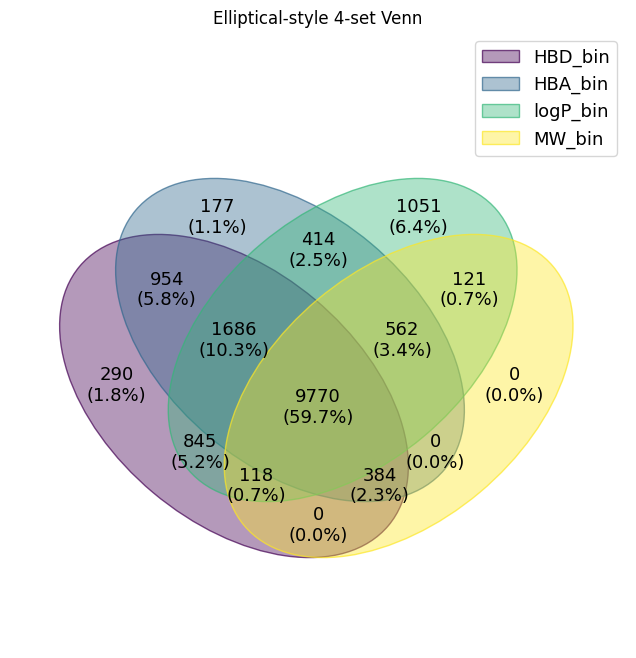

In [105]:
#sets = {c: set(csd_df.index[df[c] == 1]) for c in bin_cols}
sets = {c: set(df.index[df[c] == 1]) for c in bin_cols}
plt.figure(figsize=(8, 8))
# use {size} not {count}; {percentage} is percent of the union
v = venn(sets, fmt="{size}\n({percentage:.1f}%)")
plt.title("Elliptical-style 4-set Venn")
plt.show()

c:\Users\dkondinskaia\CCDC\ccdc-software\csd-python-api\miniconda\envs\sandpit\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
c:\Users\dkondinskaia\CCDC\ccdc-software\csd-python-api\miniconda\envs\sandpit\Lib\site-packages\upsetplot\plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will

<Figure size 1000x600 with 0 Axes>

c:\Users\dkondinskaia\CCDC\ccdc-software\csd-python-api\miniconda\envs\sandpit\Lib\site-packages\matplotlib\text.py:762: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  posx = float(self.convert_xunits(x))
c:\Users\dkondinskaia\CCDC\ccdc-software\csd-python-api\miniconda\envs\sandpit\Lib\site-packages\matplotlib\text.py:762: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  posx = float(self.convert_xunits(x))
c:\Users\dkondinskaia\CCDC\ccdc-software\csd-python-api\miniconda\envs\sandpit\Lib\site-packages\matplotlib\text.py:762: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure 

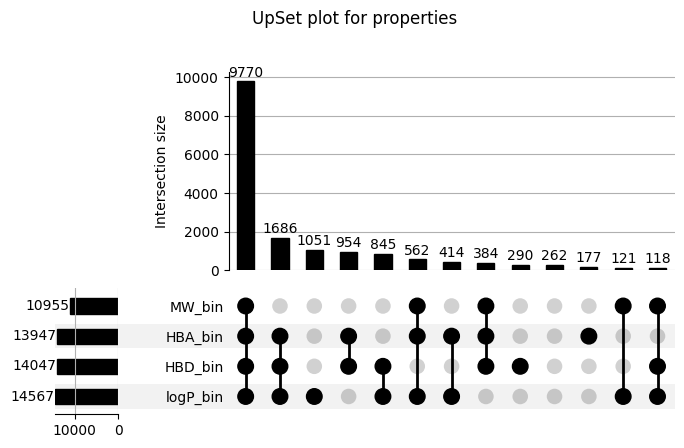

In [109]:
bin_cols = ["HBD_bin", "HBA_bin", "logP_bin", "MW_bin"]

#csd_df[bin_cols] = csd_df[bin_cols].fillna(0).astype(int)
df[bin_cols] = df[bin_cols].fillna(0).astype(int)

# Ensure binary / boolean
#csd_df[bin_cols] = csd_df[bin_cols].fillna(0).astype(bool)
df[bin_cols] = df[bin_cols].fillna(0).astype(bool)

# Create upset data (NO sort_by here)
#data = from_indicators(bin_cols, csd_df)
data = from_indicators(bin_cols, df)

# Plot
plt.figure(figsize=(10, 6))
up = UpSet(
    data,
    subset_size="count",
    show_counts=True,
    sort_by="cardinality"
)

up.plot()
plt.suptitle("UpSet plot for properties", y=1.02)
plt.show()